# Physical Constants

This notebook defines the fundamental physical constants used in the analytic implementation of the Bethe-Bloch equation. All values are sourced from authoritative references:

- **[CODATA 2022](https://physics.nist.gov/cuu/Constants/index.html)** — Committee on Data for Science and Technology
- **[PDG 2024](https://pdg.lbl.gov/2026/html/computer_read.html)** — Particle Data Group

These constants are consistent with the theoretical derivation presented in *Bethe_Full_Derivation.pdf* (report directory).

## Scope

These constants are specifically designed to support the **non-relativistic Bethe formula** in its pure form, *without* shell corrections, Barkas effects, Bloch corrections, or density effects. For complete details on the theoretical framework and project scope, refer to *Bethe_Full_Derivation.pdf* and the full project report (TO DO).


In [4]:
#   Electron rest mass energy m_e*c^2 in MeV (CODATA, 2022)
ELECTRON_MASS_MEV = 0.51099895069

#   Proton rest mass energy m_e*c^2 in MeV (CODATA, 2022)
PROTON_MASS_MEV = 938.27208943

#   PDG's K constant: K = 4*pi*N_A*r_e^2*m_e^2, en MeV*cm^2/mol
#   (previously verified against own theoretical derivation, Sect. 2.6 of
#   Bethe_Full_Derivation.pdf file in the report directory, coinciding
#   with PDF 2024 Sect 34.2.1)
K_MEV_CM2_PER_MOL = 0.307075

#   Conversion factor eV -> MeV
EV_TO_MEV = 1e-6

## Material Properties

This section defines the properties of the four absorber materials used throughout the project.

### Data Sources and Verification

All material parameters—**atomic number (Z)**, **atomic mass (A)**, **mean excitation energy (I)**, and **density (ρ)**—have been carefully verified against authoritative references:

- [**NIST STAR Composition Database**](https://www.nist.gov/cgi-bin/Star/compos.pl)
- [**NIST Periodic Table (June 2024)**](www.nist.gov/system/files/documents/2024/06/25/NIST_periodictable_June24_iupac.pdf)

Each material corresponds to a specific NIST material number (`matno`) that matches the reference data downloaded in the `nist_data` directory.

### Rationale for NIST Parameter Adoption

The values of **I** and **density** are deliberately taken from NIST PSTAR to ensure that any discrepancies between:
- Our theoretical predictions (pure Bethe formula)
- NIST PSTAR reference data

can be attributed **solely** to the omitted corrections (shell, Barkas, Bloch, density effects) rather than differences in material property definitions.

### Treatment of Compounds: Water

For **water** (H₂O), being a compound rather than a pure element, the effective Z/A ratio is calculated using the **Bragg additivity rule**:

$$\left(\frac{Z}{A}\right)_{\text{eff}} = \sum_i w_i \left(\frac{Z_i}{A_i}\right)$$

where $w_i$ is the mass fraction of *i-th* constituent element.

This is the standard approach for compounds and mixtures in stopping power calculations, as documented in **ICRU Report 37**.


In [5]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Material:
    name: str
    Z_over_A: float     #   Effective Z/A [mol/g]
    I_eV: float     #   Mean excitation energy [eV]
    rho_g_cm3: float    #   Density [g/cm^3]
    matno: str      # NIST STAR material number (for traceability)

#   Pure elements: Z/A = Z_atomic / (molar mass)

ALUMINIUM = Material(
    name="ALUMINIUM",
    Z_over_A=13.0/26.982,
    I_eV=166,
    rho_g_cm3=2.69890,
    matno="013",
)

COPPER = Material(
    name="COPPER",
    Z_over_A=29.0/63.546,
    I_eV=322,
    rho_g_cm3=8.96000,
    matno="029",
)

LEAD = Material(
    name="LEAD",
    Z_over_A=82.0/207.2,
    I_eV=823.0,
    rho_g_cm3=11.35,
    matno="082",
)

#   Liquid water: compound, Z/A by the Bragg rule
#   Composition by mass fraction (NIST Star, matno = 276):
#   H (Z=1, A=1.008);   w=0.111894
#   O (Z=8, A=15.999);   w=0.888106
WATER_Z_OVER_A = (0.111894 * (1.0/1.008) + 0.888106 * (8.0/15.999))

WATER = Material(
    name="WATER",
    Z_over_A=WATER_Z_OVER_A,
    I_eV=75.0,
    rho_g_cm3=1.0,
    matno="276",
)

#   Iteration-friendly dictionary
MATERIALS = {
    "water": WATER,
    "aluminium": ALUMINIUM,
    "copper": COPPER,
    "lead": LEAD,
}

if __name__ == "__main__":
    #   Quick sanity check: water's Z/A should give ~ 0.55509 (See
    #   "Atomic and nuclear properties" from PDG)
    for key, mat in MATERIALS.items():
        print(f"{mat.name:15s} Z/A = {mat.Z_over_A:.5f}    I = {mat.I_eV:.6f} [eV]   "
              f"rho = {mat.rho_g_cm3:.6f} [g/cm^3]  (matno={mat.matno})")

WATER           Z/A = 0.55509    I = 75.000000 [eV]   rho = 1.000000 [g/cm^3]  (matno=276)
ALUMINIUM       Z/A = 0.48180    I = 166.000000 [eV]   rho = 2.698900 [g/cm^3]  (matno=013)
COPPER          Z/A = 0.45636    I = 322.000000 [eV]   rho = 8.960000 [g/cm^3]  (matno=029)
LEAD            Z/A = 0.39575    I = 823.000000 [eV]   rho = 11.350000 [g/cm^3]  (matno=082)


# Analytical Bethe-Bloch Implementation

## Overview

This module implements the **relativistic Bethe-Bloch equation** for protons in its pure form, deliberately excluding shell corrections, Barkas effects, Bloch corrections, and density effects.

## Theoretical Foundation

The implementation corresponds exactly to the equation presented in the **"Relativistic Bethe"** section of the theoretical derivation document (see *Bethe_Full_Derivation.pdf* in the report directory), specifically the subsection *"Distribution of the relativistic correction and assembled result"*.

### Fundamental Equation

The linear stopping power in its basic form:

$$-\frac{dE}{dx} = \frac{4\pi z^2 e^4 n_a Z}{m_e c^2 \beta^2} \left[\ln\left(\frac{2m_e c^2 \beta^2 \gamma^2}{I}\right) - \beta^2\right]$$

### Mass Stopping Power Form

Rewritten in the standard **mass stopping power** convention [MeV·cm²/g] used by PDG and NIST PSTAR:

$$S(T) = -\frac{1}{\rho}\frac{dE}{dx} = K \cdot z^2 \cdot \frac{Z}{A} \cdot \frac{1}{\beta^2} \left[\ln\left(\frac{2m_e c^2 \beta^2 \gamma^2}{I}\right) - \beta^2\right]$$

where $K = 4\pi N_A r_e^2 m_e c^2$ (see constants defined above).

---

## ⚠️ Important Scope and Limitations

### **Deliberately Excluded Corrections**

This implementation **does NOT include**:

- **Shell correction** (C/Z term)
- **Barkas correction** (z³ term)
- **Bloch correction** (z², beyond Born approximation)
- **Density effect** (Sternheimer δ(βγ) correction)

### **Physical Justification**

These corrections are deliberately omitted for well-documented physical reasons (see *"Project Scope and Future Work"* section in the theoretical derivation document).

### **Expected Behavior**

⚠️ **Consequence**: This function will systematically **underestimate** the stopping power reported by:
- NIST PSTAR database
- Geant4 simulations

The discrepancy increases for:
- **Low energies** (< 10 MeV)
- **High-Z materials** (e.g., lead)

### **This is NOT a bug** — it is an **expected and documented result** of the project scope.

---

## Validity Range

This implementation is valid in the **Born approximation** regime, characterized by the Sommerfeld parameter:

$$\eta = \frac{z\alpha}{\beta} \ll 1$$

For **protons** in the energy range **3–300 MeV**:
- η ranges from ~0.011 to ~0.09

See section *"Validity criterion: the Sommerfeld parameter"* in the derivation document for detailed discussion.


In [6]:
import numpy as np

def beta_gamma_from_kinetic_energy(T_MeV, particle_mass_MeV=PROTON_MASS_MEV):
    """
    Calculate relativistic beta and gamma factors from the kinetic energy
    T (in MeV) of a particle at a rest mass energy equivalent particle_mass_MeV,
    which is taken to be that of the proton by default.

    The used formulas are

    gamma = 1 + T / (Mc^2)
    beta = sqrt(1 - 1/gamma^2)

    Parameters
    ----------
    :param T_MeV: Kinetic energy in MeV (array-like)
    :param particle_mass_MeV: Particle mass in MeV (float)

    Returns
    -------
    :return: Tuple (beta, gamma)
    """
    T_MeV = np.asarray(T_MeV, dtype=float)
    gamma = 1.0 + T_MeV / particle_mass_MeV
    beta = np.sqrt(1.0 - 1.0 / gamma**2)
    return beta, gamma

def mass_stopping_power(T_MeV, material: Material, z=1, particle_mass_MeV=PROTON_MASS_MEV):
    """"
    Parameters
    ----------
    :param T_MeV: Kinetic energy in MeV (array-like)
    :param material: Absorber material (See defined materials above)
    :param z: Projectile charge in e units,
                taken as 1 for protons by default (see below) (float)
    :param particle_mass_MeV: Particle mass in MeV (float)

    Returns
    -------
    :return: S: Mass stopping power in MeV cm^2/g (np.ndarray)
    """
    T_MeV = np.asarray(T_MeV, dtype=float)
    beta, gamma = beta_gamma_from_kinetic_energy(T_MeV, particle_mass_MeV)

    I_MeV = material.I_eV * EV_TO_MEV

    #   Calculation of the logarithm argument
    log_arg = (2.0 * ELECTRON_MASS_MEV * beta**2 * gamma**2) / I_MeV

    main_bracket = np.log(log_arg) - beta**2

    S = K_MEV_CM2_PER_MOL * z**2 * material.Z_over_A * main_bracket / beta**2

    return S

def linear_stopping_power(T_MeV, material: Material, z=1, particle_mass_MeV=PROTON_MASS_MEV):
    """
    Linear stopping power -(dE/dx) in MeV/cm, for a particle
    with kinetic energy T_MeV in MeV in `material`. This is
    simply the mass stopping power times the material density.
    """
    S_mass = mass_stopping_power(T_MeV, material, z, particle_mass_MeV)
    return S_mass * material.rho_g_cm3

def validity_check(T_MeV, particle_mass_MeV=PROTON_MASS_MEV):
    """
    Returns a dictionary with beta, gamma, beta*gamma, and a Boolean flag
    indicating whether the point is within the validity range of
    the Bethe formula WITHOUT corrections (beta*gamma >= 0.1, i.e.,
    T >= 4.68 MeV for protons). See Sec. "Project Scope and
    Future Work" of the derivation document.
    """
    beta, gamma = beta_gamma_from_kinetic_energy(T_MeV, particle_mass_MeV)
    bg = beta * gamma
    return{
        "beta": beta,
        "gamma": gamma,
        "beta_gamma": bg,
        "valid_uncorrected_bethe": bg >= 0.1,
    }

if __name__ == "__main__":
    #   Sanity check: 100 MeV proton in water
    T_test = 100.0
    S = mass_stopping_power(T_test, WATER)
    vc = validity_check(T_test)
    print(f"Proton {T_test} MeV in water:")
    print(f"    beta = {vc['beta']:.5f}, gamma = {vc['gamma']:.5f}, "
          f"    beta*gamma = {vc['beta_gamma']:.4f}")
    print(f"    S (no corrections) = {S:.4f} [MeV cm^2/g]")
    print(f"NIST PSTAR Reference Value (with corrections) ~ 7.289,")
    print("see 'pstar_water.csv' file for comparison with NIST PSTAR values.")
    dif_porc = (np.abs(S - 7.289) / 7.289) * 100
    print(f"Difference from NIST PSTAR value: {dif_porc:.2f}%")
    if dif_porc < 2:
        print("Within 2% of NIST PSTAR value.")
    else:
        print("Over 2% of NIST PSTAR value.")


Proton 100.0 MeV in water:
    beta = 0.42820, gamma = 1.10658,     beta*gamma = 0.4738
    S (no corrections) = 7.2909 [MeV cm^2/g]
NIST PSTAR Reference Value (with corrections) ~ 7.289,
see 'pstar_water.csv' file for comparison with NIST PSTAR values.
Difference from NIST PSTAR value: 0.03%
Within 2% of NIST PSTAR value.


## Basic tests

The following suite of unit tests rigorously validates the core analytical functions of this module. **`test_beta_gamma_limits`** verifies the correct asymptotic relativistic behaviour of `beta_gamma_from_kinetic_energy`, ensuring γ → 1 at near-zero energies and γ = 2 exactly at *T* = *Mc*². **`test_stopping_power_positive_and_finite`** confirms that `mass_stopping_power` returns physically meaningful (positive, finite) values across the full clinical energy range for all four absorber materials. **`test_stopping_power_decreasing_with_energy_in_clinical_range`** asserts the expected monotonic decrease of *S*(*T*) with energy in the 3–300 MeV window, where the 1/β² dominance over the logarithmic relativistic argument governs the curve's shape. **`test_water_100mev_matches_nist_within_1pct`** provides a quantitative cross-check against the NIST PSTAR reference value of 7.289 MeV·cm²/g at 100 MeV in water — a particularly clean benchmark since shell corrections are nearly negligible there. **`test_linear_stopping_power_scales_with_density`** ensures self-consistency between `mass_stopping_power` and `linear_stopping_power` by verifying the ρ-scaling identity. **`test_charge_scaling`** enforces the fundamental *z*² dependence of the Bethe formula. Finally, **`test_validity_flag_at_clinical_lower_bound`** probes the `validity_check` function at the boundaries of the clinical range, flagging the well-documented region of highest theoretical uncertainty near the Bragg peak.


In [7]:
def test_beta_gamma_limits():
    #   As T -> 0 should give beta -> 0
    beta, gamma = beta_gamma_from_kinetic_energy(1e-6)  #   1 [eV]
    assert beta < 1e-3
    assert np.isclose(gamma, 1.0, atol=1e-6)

    #   T = Mc^2 -> gamma = 2
    beta, gamma = beta_gamma_from_kinetic_energy(PROTON_MASS_MEV)
    assert np.isclose(gamma, 2.0, atol=1e-6)
    assert beta < 1.0

def test_stopping_power_positive_and_finite():
    energies = np.array([3.0, 10.0, 62.3, 100.0, 200.0, 300.0])
    for mat in (WATER, ALUMINIUM, COPPER, LEAD):
        S = mass_stopping_power(energies, mat)
        assert np.all(np.isfinite(S))
        assert np.all(S > 0)

def test_stopping_power_decreasing_with_energy_in_clinical_range():
    #   In the 3-300 MeV range (over the ionization minima),
    #   dE/dx should be monotonously decreasing as the energy increases
    #   as '-1/beta^2' dominates over the logarithm with the relativistic
    #   argument increases in this range.
    energies = np.linspace(3.0, 300.0, 50)
    S = mass_stopping_power(energies, WATER)
    assert np.all(np.diff(S) < 0), "S(T) should be monotonously decreasing as the energy increases"

def test_water_100mev_matches_nist_within_1pct():
    #   Sanity check against NIST PSTAR value (7.289 [MeV cm^2/g],
    #   again, see 'pstar_water.csv' file in the nist_data directory).
    #   A 1% difference is allowed since, for water, the shell correction
    #   is nearly negligible in the considered energy range.
    S = mass_stopping_power(100.0, WATER)
    nist_reference = 7.289
    rel_diff = abs(S - nist_reference) / nist_reference
    assert rel_diff < 0.01, f"Difference {rel_diff:.4f}% exceeds expected 1%"

def test_linear_stopping_power_scales_with_density():
    T = 100.0
    S_mass = mass_stopping_power(T, LEAD)
    S_linear = linear_stopping_power(T, LEAD)
    assert np.isclose(S_linear, S_mass * LEAD.rho_g_cm3)

def test_charge_scaling():
    #   Stopping power should scale as z^2
    #   (testing with z=2, α-like)
    T = 100.0
    S_z1 = mass_stopping_power(T, WATER, z=1)
    S_z2 = mass_stopping_power(T, WATER, z=2)
    assert np.isclose(S_z2, 4 * S_z1, rtol=1e-10)

def test_validity_flag_at_clinical_lower_bound():
    #   The lower bound of the clinical range (3 MeV) should
    #   be close or under the validity threshold:
    #   beta * gamma >= 0.1
    vc_3mev = validity_check(3.0)
    vc_300mev = validity_check(300.0)
    assert vc_300mev["valid_uncorrected_bethe"]
    #   At 3 MeV it is expected for beta*gamma to be lower
    #   than at higher energies, although the exact result
    #   (wether it is valid or not) is left as informative,
    #   not as a strict assertion, since it is the point of
    #   highest documented uncertainty in the whole project.
    print(f"beta*gamma a 3 MeV: {vc_3mev['beta_gamma']:.4f} "
          f"(umbral de validez sin correcciones: 0.1")

def _run_all():
    tests = [
        test_beta_gamma_limits,
        test_stopping_power_positive_and_finite,
        test_stopping_power_decreasing_with_energy_in_clinical_range,
        test_water_100mev_matches_nist_within_1pct,
        test_linear_stopping_power_scales_with_density,
        test_charge_scaling,
        test_validity_flag_at_clinical_lower_bound,
    ]
    n_ok = 0
    for t in tests:
        try:
            t()
            print(f"OK  {t.__name__}")
            n_ok += 1
        except AssertionError as e:
            print(f"FAIL {t.__name__}: {e}")
    print(f"{n_ok}/{len(tests)} tests passed")

if __name__ == "__main__":
    _run_all()


OK  test_beta_gamma_limits
OK  test_stopping_power_positive_and_finite
OK  test_stopping_power_decreasing_with_energy_in_clinical_range
OK  test_water_100mev_matches_nist_within_1pct
OK  test_linear_stopping_power_scales_with_density
OK  test_charge_scaling
beta*gamma a 3 MeV: 0.0800 (umbral de validez sin correcciones: 0.1
OK  test_validity_flag_at_clinical_lower_bound
7/7 tests passed


## Output Generation

Generates **dE/dx vs. Energy** curves (relativistic Bethe, *without corrections*) for the four project materials, covering the **clinical range of 3–300 MeV**, with an extended margin up to **1000 MeV** for visualization purposes only (outside the clinical scope).

### Output Files

| File | Description |
|------|-------------|
| `python/analytic/output/bethe_bloch_analytic_<material>.csv` | Per-material stopping power data |
| `python/analytic/output/bethe_bloch_analytic_all.csv` | Combined dataset |
| `python/analytic/output/dEdx_vs_energy.png` | All 4 curves (log-log scale) |

### Combined CSV Columns

`material` · `T_MeV` · `S_mass_MeV_cm2_g` · `S_linear_MeV_cm` · `beta` · `gamma` · `beta_gamma` · `valid_uncorrected_bethe`


Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bathe_analytic_water.csv (54 filas)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bathe_analytic_aluminium.csv (54 filas)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bathe_analytic_copper.csv (54 filas)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bathe_analytic_lead.csv (54 filas)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bathe_analytic_all.csv (216 filas)
Saved /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/dEdx_vs_energy.png


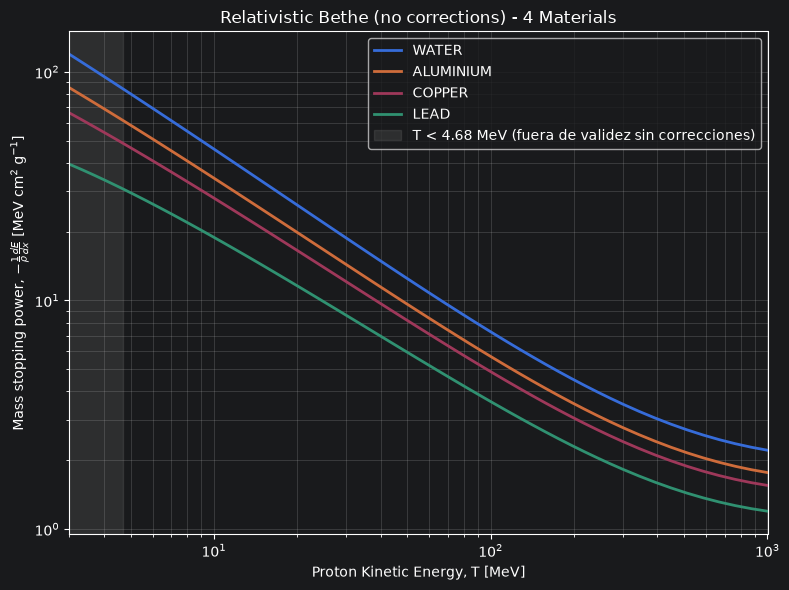

In [17]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "output")

def build_energy_grid():
    """
    Energy grid: 44 log-spaced points in the clinical range of 3–300 MeV,
    with an extended margin up to 1000 MeV with 10 additional points for
    visualization purposes only.
    """
    clinical = np.logspace(np.log10(3.0), np.log10(300.0), 44)
    extension = np.logspace(np.log10(300.0), np.log10(1000.0), 10)
    return np.concatenate([clinical, extension])

def generate_all():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    energies = build_energy_grid()

    all_rows = []
    for key, mat in MATERIALS.items():
        S_mass = mass_stopping_power(energies, mat)
        S_linear = linear_stopping_power(energies, mat)
        vc = validity_check(energies)

        df = pd.DataFrame({
            "material": mat.name,
            "T_MeV": energies,
            "S_mass_MeV_cm2_g": S_mass,
            "S_linear_MeV_cm": S_linear,
            "beta": vc["beta"],
            "gamma": vc["gamma"],
            "beta_gamma": vc["beta_gamma"],
            "valid_uncorrected_bethe": vc["valid_uncorrected_bethe"],
        })

        out_path = os.path.join(OUTPUT_DIR, f"bathe_analytic_{key}.csv")
        df.to_csv(out_path, index=False)
        print(f"Written {out_path} ({len(df)} filas)")

        all_rows.append(df)

    combined = pd.concat(all_rows, ignore_index=True)
    combined_path = os.path.join(OUTPUT_DIR, "bathe_analytic_all.csv")
    combined.to_csv(combined_path, index=False)
    print(f"Written {combined_path} ({len(combined)} filas)")

    return combined

def plot_curves(combined: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 6))

    for key, mat in MATERIALS.items():
        sub = combined[combined["material"] == mat.name]
        ax.plot(sub["T_MeV"], sub["S_mass_MeV_cm2_g"], label=mat.name, linewidth=2)

    #   Shade the region under the validity threshold (beta*gamma < 0.1)
    ax.axvspan(0, 4.68, color="grey", alpha=0.2,
               label="T < 4.68 MeV (fuera de validez sin correcciones)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Proton Kinetic Energy, T [MeV]")
    ax.set_ylabel(r"Mass stopping power, $-\frac{1}{\rho}\frac{dE}{dx}$ [MeV cm$^2$ g$^{-1}$]")
    ax.set_title("Relativistic Bethe (no corrections) - 4 Materials")
    ax.set_xlim(3, 1000)
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

    fig.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, "dEdx_vs_energy.png")
    fig.savefig(out_path, dpi=300)
    print(f"Saved {out_path}")
    #plt.close(fig)

if __name__ == "__main__":
    combined = generate_all()
    plot_curves(combined)